# **The Interrogation**

### Session 4 live demonstration — EDA for predictive signal · BDAT05

> **Jerald B. Bongalos**

> LPU–Laguna, College of Business and Accountancy · Term 1, AY 2026–2027

---

**What this notebook is.** A live walkthrough of exploratory data analysis done the *predictive* way — on a slice nobody owns (**branch-day revenue**), so your own P3 stays yours. Watch the rhythm: every chart gets asked the same question — *"Does this help me predict, or does it just describe?"*

**The frame, in three lines.** Each month the Operations lead sets staffing and stock. To decide well, she needs demand predicted in advance. Before any model earns that job, we interrogate the data: what patterns exist, what travels forward, what is trap.


**💬 Discussion.** Before any analysis, we record the exact versions of the libraries this notebook runs on. This is not decoration — it is reproducibility: a notebook is graded on whether it re-runs top-to-bottom (*Restart & Run all*), and a printed version line documents exactly what produced our numbers. If a classmate's results ever differ from ours, this line is where the investigation starts.

> Note that `plt` (pyplot) is only a module inside matplotlib — the version number lives on the parent package, which is why we import `matplotlib` itself here.

In [2]:
import matplotlib
import sys
print("python    ", sys.version.split()[0])
print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("matplotlib", matplotlib.__version__)

python     3.13.15
pandas     2.2.3
numpy      2.1.3
matplotlib 3.10.0


**🔎 Reading the output — what these versions mean for re-running this notebook.**

These four numbers are a snapshot of the environment, and each carries a real implication:

- **pandas 2.2.3** — we are on the pandas 2.x line, *not* pandas 3. This matters because pandas 3 changes visible behavior: text columns report as `str` instead of `object` in `df.info()`, and stricter copy rules can turn code that silently worked into code that raises errors. If Colab upgrades underneath us, our *numbers* should not change — but some outputs will *look* different, and a few shortcuts may stop running.
- **numpy 2.1.3** — the 2.x line removed several old aliases that tutorials still use (e.g., `np.float_`). Code copied from an older tutorial or an LLM trained on older examples may fail here even though it "worked for someone else." When that happens, read the error before blaming yourself — it is usually a version gap, not a logic gap.
- **matplotlib 3.10.0** — charts are the most stable of the three; expect cosmetic differences (default colors, spacing) across versions, never different data.
- **Python 3.13.15** — recent enough that all three libraries above are fully supported; nothing in this notebook uses version-fragile language features.

**The general lesson:** results are reproducible only *relative to an environment*. Colab upgrades its libraries without asking us — so the same notebook, re-run months from now, may print different version numbers, emit new deprecation warnings, or format outputs differently, while the *analysis itself* stays correct.

>That is exactly why this cell exists: when something looks different on a re-run, compare version lines first, code second.

---
## Step 1 · Load and rebuild the clean base

**💬 Discussion.** We start from `sales_transactions.csv` and replay the Session 3 cleaning in one cell — deduplicate, repair the dirty BranchIDs, parse dates, drop the dateless. Watch the arithmetic at the end: every removed row is *counted*, because nothing changes silently.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

def drive_url(file_id):
    return f"https://drive.google.com/uc?export=download&id={file_id}"

sales = pd.read_csv(drive_url("1LlA5ni-10NzZq6ODU4eq8AlB6zi0WlDA"))
n0 = len(sales)

sales = sales.drop_duplicates()                                   # the 23 duplicate SaleIDs
sales["BranchID"] = (sales["BranchID"].astype(str).str.strip()
                     .str.upper().str.replace("-", "", regex=False))   # the 6 dirty variants
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales = sales.dropna(subset=["Date"])                             # the 12 dateless rows

print(f"raw: {n0}  →  clean: {len(sales)}  (removed {n0 - len(sales)}: 23 duplicates + 12 dateless)")

raw: 10589  →  clean: 10554  (removed 35: 23 duplicates + 12 dateless)


**🔎 Reading the output.** 10,589 in, **10,554** out, and the difference is fully accounted for: 23 + 12 = 35. That one printed line is Lawrence's cleaning log and AJ's provenance rule, welded together. From here on, every number we see is traceable to this base.


---
## Step 2 · Build the demonstration slice — branch-day revenue

**💬 Discussion.** One row = one branch on one day: revenue and order count. A *finer* grain than your monthly P2 slices — deliberately, because days are where distributions, weekday rhythms, and outliers actually live. State your grain, then count your rows. Always.


In [4]:
sales["Day"] = sales["Date"].dt.normalize()   # date with time stripped, stays datetime64

bd = (sales
      .groupby(["BranchID", "Day"], as_index=False)
      .agg(Revenue=("Amount", "sum"), Orders=("SaleID", "nunique")))

print("rows (branch-days):", len(bd))
bd.head()

rows (branch-days): 3143


,BranchID,Day,Revenue,Orders
0,B01,2025-01-01,1230.0,6
1,B01,2025-01-02,845.0,3
2,B01,2025-01-03,1625.0,3
3,B01,2025-01-04,790.0,4
4,B01,2025-01-05,470.0,3


**🔎 Reading the output.** **3,143 branch-days** — 6 branches × ~18 months of open days. Compare that to your 108-row monthly tables: same store, thirty times the resolution. More rows means distributions become visible; it also means noise becomes visible. Both are about to matter.


---
## Step 3 · Univariate — what does a "normal day" look like?

**💬 Discussion.** Before any relationship, one variable at a time. `describe()` gives the skeleton; a histogram gives the shape. The question we bring: *is a typical day typical?* — because "predict the average" only works if the average represents anything.


count    3143.0
mean      798.8
std       472.7
min        75.0
25%       460.0
50%       730.0
75%      1045.0
max      3345.0
Name: Revenue, dtype: float64

skewness: 1.15


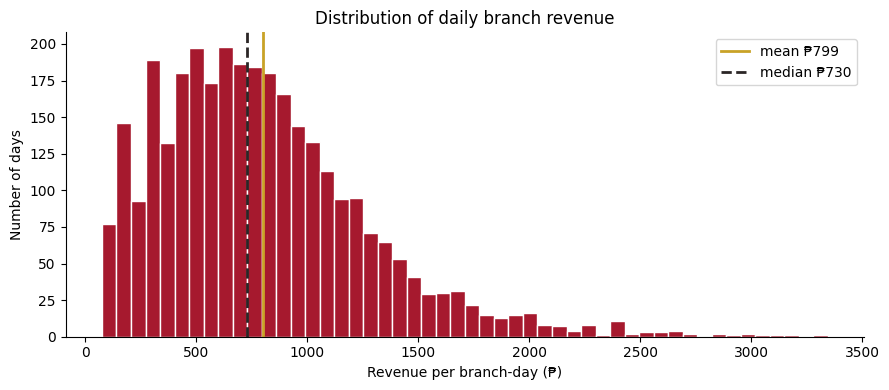

In [5]:
print(bd["Revenue"].describe().round(1))
print("\nskewness:", round(bd["Revenue"].skew(), 2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(bd["Revenue"], bins=50, color="#A6192E", edgecolor="white")
ax.axvline(bd["Revenue"].mean(),   color="#C9A227", lw=2, label=f"mean ₱{bd['Revenue'].mean():,.0f}")
ax.axvline(bd["Revenue"].median(), color="#2B2626", lw=2, ls="--", label=f"median ₱{bd['Revenue'].median():,.0f}")
ax.set_title("Distribution of daily branch revenue")
ax.set_xlabel("Revenue per branch-day (₱)"); ax.set_ylabel("Number of days")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

**🔎 Reading the output.** Mean **₱799**, median **₱730**, skewness **+1.15** — a right-skewed distribution with a long tail of big days. The mean sits *above* the median because the tail drags it there: the "average day" is already a slightly misleading idea. **Predictive consequence:** a model trained to hit the mean will chronically over-shoot the typical day and still miss the big ones — which is exactly why field 10 asked which miss costs more. Skew is not a statistics trivia fact; it is a staffing decision wearing a disguise.


---
## Step 4 · Outliers — the 87 days that refuse to be typical

**💬 Discussion.** The IQR fence (Q3 + 1.5×IQR) is a *flashlight*, not a judge: it shows us unusual days; it does not tell us to delete them. Every outlier gets the AJ question: is this an error, or is this Tuesday telling the truth loudly?


In [6]:
q1, q3 = bd["Revenue"].quantile([.25, .75])
fence = q3 + 1.5 * (q3 - q1)
outliers = bd[bd["Revenue"] > fence]

print(f"upper fence: ₱{fence:,.0f}   |   days above it: {len(outliers)} of {len(bd)}")
print("\nTop 5 revenue days:")
print(outliers.nlargest(5, "Revenue").to_string(index=False))

upper fence: ₱1,922   |   days above it: 87 of 3143

Top 5 revenue days:
BranchID        Day  Revenue  Orders
     B02 2026-03-13   3345.0       5
     B01 2026-05-13   3200.0       6
     B01 2025-05-31   3130.0       8
     B05 2025-11-08   3045.0       5
     B01 2025-04-11   2990.0       7


**🔎 Reading the output.** **87 days above ₱1,922** — about 2.8% of all branch-days. Look at the champion: **B02, 13 March 2026, ₱3,345 from only 5 orders** — that is ~₱670 per order against a store average near ₱230. That's not a busy day; that's a *big-ticket* day (merchandise? a bulk order?). **Decision: keep, and flag.** Deleting these days would teach the model that big days don't happen — and big days are precisely when staffing decisions bite. Signal, not dirt. Write that in the log.


---
## Step 5 · Bivariate — the weekday rhythm

**💬 Discussion.** Now relationships. First candidate predictor: *what day of the week is it?* — knowable infinitely far in advance, which makes it the cleanest kind of feature. If revenue moves with weekday, we have found signal that travels forward.


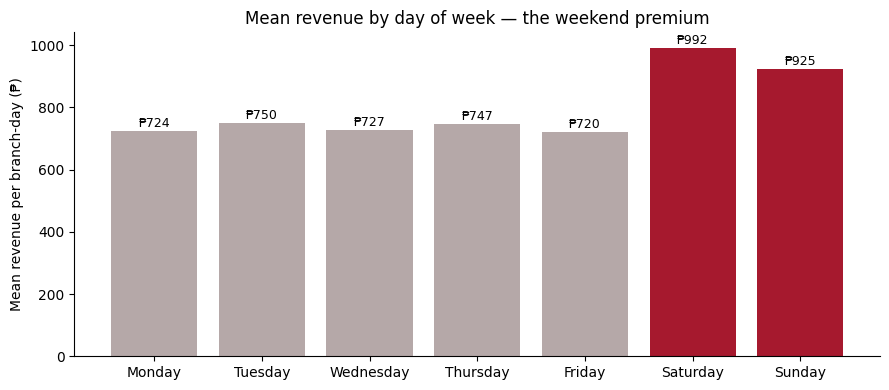

In [7]:
wk = (bd.assign(Weekday=bd["Day"].dt.day_name())
        .groupby("Weekday")["Revenue"].mean()
        .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#B5A8A8"]*4 + ["#B5A8A8", "#A6192E", "#A6192E"]
ax.bar(wk.index, wk.values, color=colors)
ax.set_title("Mean revenue by day of week — the weekend premium")
ax.set_ylabel("Mean revenue per branch-day (₱)")
for i, v in enumerate(wk.values):
    ax.text(i, v + 12, f"₱{v:,.0f}", ha="center", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

**🔎 Reading the output.** Saturday **₱992** and Sunday **₱925** against a weekday plateau around **₱720–750** — a **weekend premium of roughly 30%**, consistent and large. This is real predictive signal: knowable in advance, mechanically connected to the decision (weekend staffing), and strong enough to beat a naive flat average on its own. Into the signal memo it goes — with a number attached, not an adjective.


---
## Step 6 · Correlation — and the trap inside it

**💬 Discussion.** `Orders` vs `Revenue`: obviously related. Let's measure it — and then ask the question the correlation coefficient never asks itself: *could I have known this predictor at prediction time?*


corr(Orders, Revenue) on branch-days: 0.734


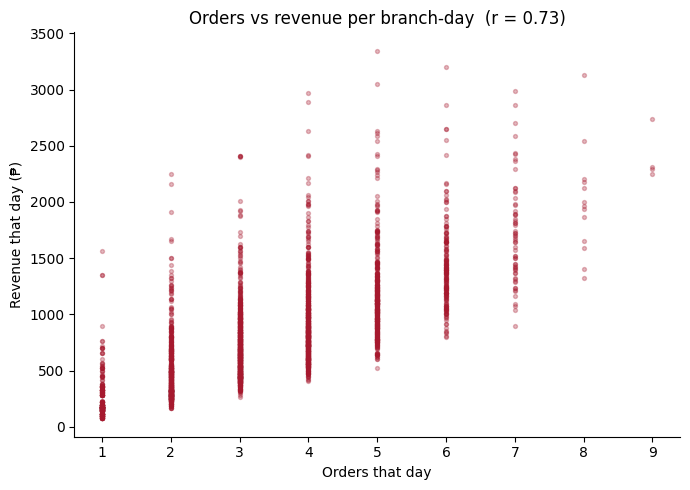

In [8]:
r = bd["Orders"].corr(bd["Revenue"])
print("corr(Orders, Revenue) on branch-days:", round(r, 3))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bd["Orders"], bd["Revenue"], s=8, alpha=0.3, color="#A6192E")
ax.set_title(f"Orders vs revenue per branch-day  (r = {r:.2f})")
ax.set_xlabel("Orders that day"); ax.set_ylabel("Revenue that day (₱)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

**🔎 Reading the output.** r = **0.73** — strong, real, and **useless as a predictor**. To know today's order count, today must already have happened — at which point you no longer need a revenue forecast. This is **concurrent leakage**: a variable measured *at the same time as* the outcome, smuggled in as if it were a cause. The vertical spread at each x-value carries the other lesson: same order count, wildly different revenue — the big-ticket effect from Step 4, again. **The rule this chart teaches: correlation ranks candidates; the calendar disqualifies them.** Ask every column: *knowable on the morning I predict? Yes → candidate. No → leak.*


---
## Step 7 · Base rates — three numbers before any model

**💬 Discussion.** Base rates are the "assume nothing changes" numbers — the floor every prediction must beat and the context every percentage lives in. Three from this business, in one cell.


In [9]:
raw = pd.read_csv(drive_url("1LlA5ni-10NzZq6ODU4eq8AlB6zi0WlDA"))

print("Walk-in rate (no CustomerID):", f"{raw['CustomerID'].isna().mean()*100:.1f}%")
print("\nPayment mix:")
print((raw["PaymentMethod"].value_counts(normalize=True)*100).round(1).astype(str) + "%")
print("\nWeekend share of revenue:",
      f"{bd[bd['Day'].dt.dayofweek >= 5]['Revenue'].sum() / bd['Revenue'].sum() * 100:.1f}%")

Walk-in rate (no CustomerID): 45.1%

Payment mix:
PaymentMethod
Cash     55.6%
GCash    31.9%
Card     12.5%
Name: proportion, dtype: object

Weekend share of revenue: 34.9%


**🔎 Reading the output.** **45.1% of transactions are walk-ins** — so any customer-level model can only ever see half the business (Teyen's future headache, worth knowing today). **Cash is 55.6%** — a "digital payments are taking over" narrative dies against this base rate. And the weekend carries an outsized share of revenue from just 2 of 7 days. Base rates don't predict — they *calibrate*: every claim in your signal memo should be able to stand next to one.


---
## Closing · What travels forward

From one afternoon of interrogation, the demonstration slice yielded:

| Finding | Predictive verdict |
|---|---|
| Right-skew, mean ≠ median (₱799 vs ₱730) | Predict carefully — the "average day" over-shoots the typical day |
| 87 big-ticket outlier days | **Keep & flag** — signal about how big days happen, not dirt |
| Weekend premium ≈ 30% | **Strong clean signal** — knowable in advance, decision-connected |
| Orders↔Revenue r = 0.73 | **Concurrent leak** — real correlation, disqualified by the calendar |
| Walk-ins 45.1%, Cash 55.6% | Base rates — the floor and the context |

That table *is* a predictive-signal memo in embryo. Yours, on your own slice, is due today — with the same discipline: **a number on every claim, a calendar-check on every predictor, and a verdict on every chart.**

*All models are wrong. The data just told us where this one will be wrong — before we've built it. That's EDA.*
